# Qué raza es??? 🐶🐱

Ya no escribiremos *montañas de código* en nuestras libretas. Toda la ingeniería de datos, módulos de arquitectura (PyTorch Lightning) y graficadores complejos han sido abstraídos a scripts dedicados (`data.py`, `models.py`, `viz.py`), así se hace en Producción. 

El notebook funcionará así: un punto de ejecución y documentación que demuestra cómo armar el rompecabezas paso a paso.

In [8]:
from sklearn.metrics import classification_report

import torch
import pytorch_lightning as pl

# Nuestros Helpers Modulares (¡Adiós código sucio!)
from models import TransferLearningPetModel
from data import get_pet_data, get_predictions
from viz import show_images_batch, plot_pca_features, plot_confusion_matrix

pl.seed_everything(42) # Reproducibilidad ante todo

Seed set to 42


42

## 1. Importar datos
El dataset de mascoteas consiste en 37 razas diferentes. Usamos la función abstraída `get_pet_data` que internamente aplica los estándares de normalización exigidos por ImageNet (`mean=[0.485, 0.456, 0.406]`, `std=[0.229...`).

Descargando/Verificando dataset OxfordIIITPet...


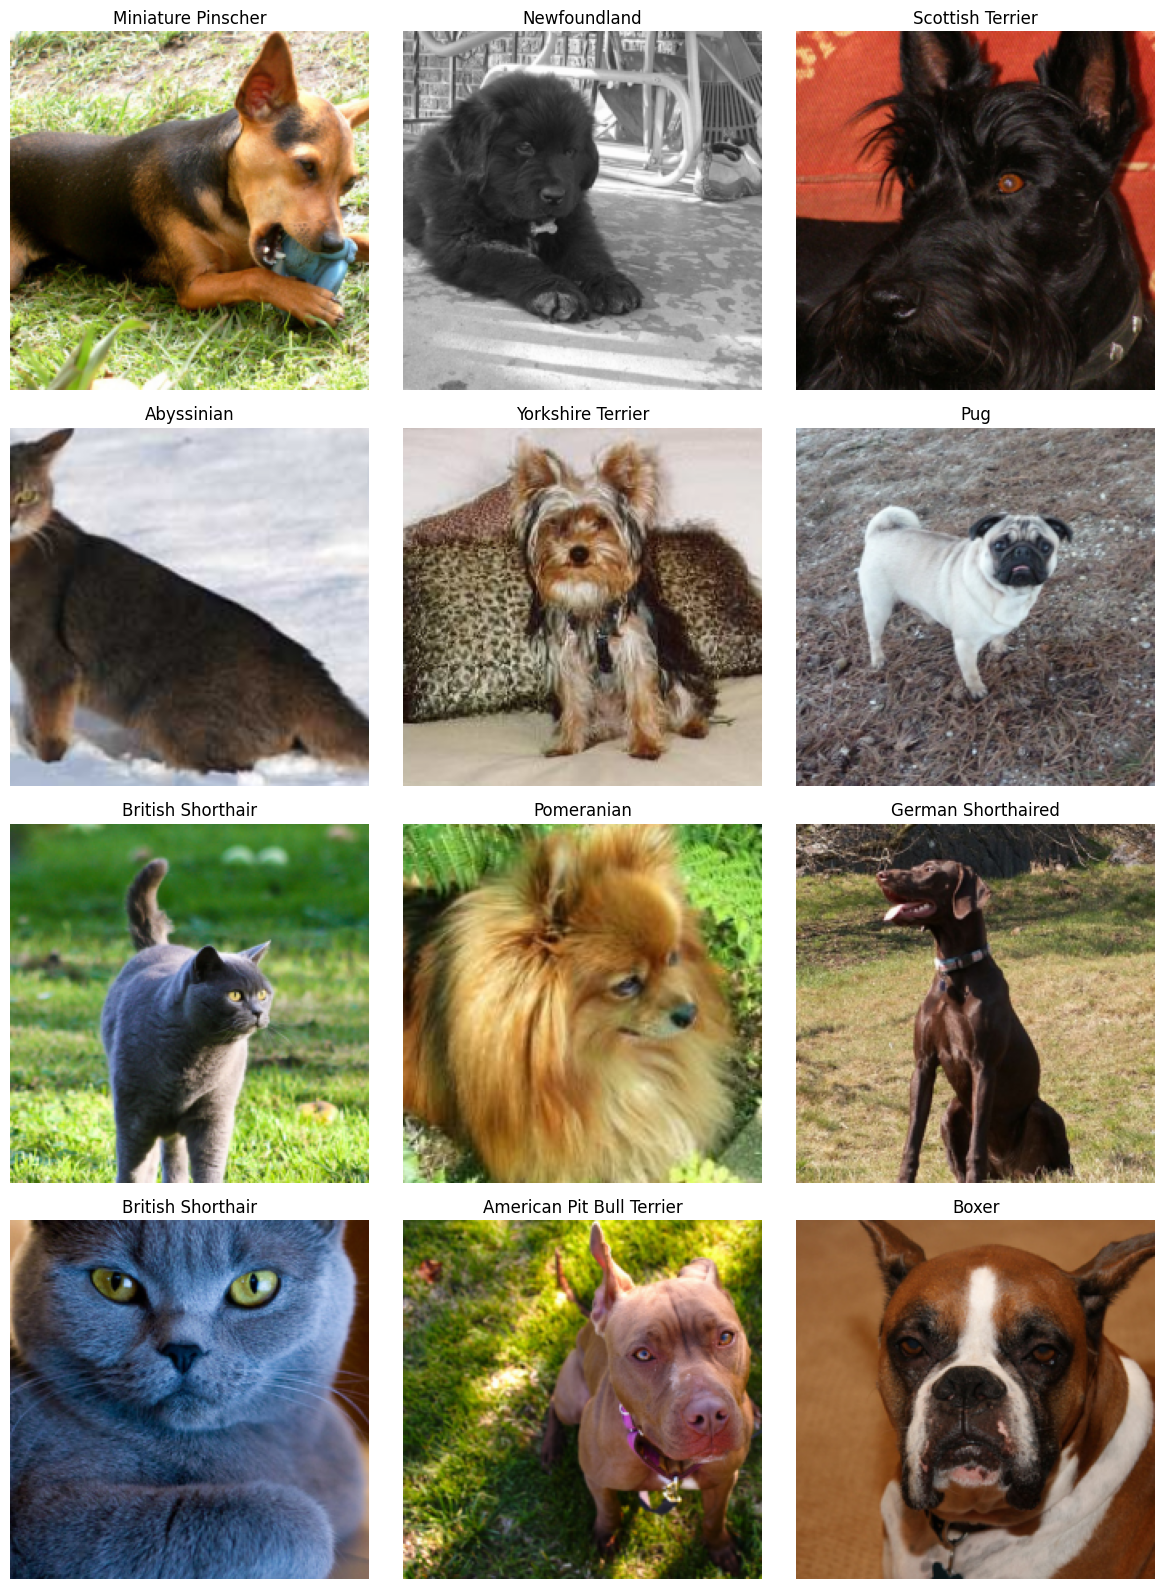

In [2]:
train_loader, val_loader, class_names = get_pet_data(data_dir='./data', batch_size=32, num_workers=8)

# Extraemos un lote para verlo
images, labels = next(iter(train_loader))
show_images_batch(images, labels, class_names, max_images=12)

## 2. Feature Extraction

Antes del *Fine-Tuning* para clasificar, qué es lo que `EfficientNet-v2-s` extrae de estas imágenes en su última capa justo antes de intentar clasificar?

In [ ]:
model = TransferLearningPetModel(model_name='efficientnet_v2_s', num_classes=37, freeze_backbone=True)
model.eval()

# Extraemos los embeddings (features vector) de este batch
with torch.no_grad():
    features = model.extract_features(images).numpy()
    labels_np = labels.numpy()

print(f"El vector de características para cada imagen tiene tamaño: {features.shape}")

El vector de características para cada imagen tiene tamaño: (32, 1280)


## 3. Son 1280 dimensiones?!
El vector de características es imposible de entender por un humano. Pero sabemos usar PCA 😉.

Si a la gráfica 3D la coloreamos por razas, vemos que la red por sí sola "agrupa" en razas parecidas

In [4]:
plot_pca_features(features, labels_np, class_names, n_components=3)

## 3.5 Separa características pero no sabe de razas

La red sabe cómo buscar formas, texturas y patas, pero la última neurona no tiene idea de cómo mapear esas formas a etiquetas como "Shiba Inu" o "Persian".

In [ ]:
# 1. Obtenemos las predicciones con nuestro modelo tal cual (recién inicializado, sin entrenar)
print("Generando predicciones con el clasificador bebé aleatorio...")
preds_random, real_labels = get_predictions(model, val_loader)

# 2. Graficamos el puro ruido:
plot_confusion_matrix(
    preds=preds_random, 
    labels=real_labels, 
    class_names=class_names, 
    title="Matriz de Confusión: Antes del Fine-Tuning (Cabeza Aleatoria)"
)


Generando predicciones con el clasificador bebé aleatorio...


In [10]:
print(classification_report(preds_random, real_labels, target_names=class_names))

                            precision    recall  f1-score   support

                Abyssinian       0.00      0.00      0.00        16
          American Bulldog       0.00      0.00      0.00        62
 American Pit Bull Terrier       0.00      0.00      0.00         1
              Basset Hound       0.00      0.00      0.00        15
                    Beagle       0.13      0.50      0.21         4
                    Bengal       0.00      0.00      0.00         1
                    Birman       0.00      0.00      0.00         9
                    Bombay       0.00      0.00      0.00        11
                     Boxer       0.00      0.00      0.00        17
         British Shorthair       0.05      0.02      0.03        55
                 Chihuahua       0.00      0.00      0.00         6
              Egyptian Mau       0.00      0.00      0.00         8
    English Cocker Spaniel       0.00      0.00      0.00         5
            English Setter       0.13      1.00

## 4. Fine-Tuning
Como nuestra meta es reconocer razas con precisión, usaremos PyTorch Lightning para re-entrenar (Fine-Tune) nuestra última capa recién añadida.

In [6]:
# Debido a Lightning, nuestro bucle de entrenamiento se reduce a esto:
trainer = pl.Trainer(max_epochs=3, 
                     accelerator='auto', # Toma GPU si en Windows hay CUDA, sino CPU
                     devices=1,
                     enable_progress_bar=True)

# Correr esta línea ejecutará todo el entrenamiento de la nueva capa
trainer.fit(model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 3070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type         | Params | Mode | FLOPs
---------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL classes\uag-deep-learning\venv\lib\site-packages\pytorch_lightning\loops\fit_loop.py:534: PossibleUserWarning:

Found 715 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.



Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


## 5. Aprendió?

Resultados después del Fine-Tuning

In [7]:
print("Obteniendo predicciones post-entrenamiento...")
# Pasamos nuestro val_loader por el modelo ahora entrenado por Lightning!
preds_trained, _ = get_predictions(model, val_loader)

# Ploteamos el aprendizaje
plot_confusion_matrix(
    preds=preds_trained, 
    labels=real_labels, 
    class_names=class_names, 
    title="Matriz de Confusión: ¡Después del Fine-Tuning!"
)

Obteniendo predicciones post-entrenamiento...


In [11]:
print(classification_report(preds_trained, real_labels, target_names=class_names))

                            precision    recall  f1-score   support

                Abyssinian       0.50      0.82      0.62        11
          American Bulldog       0.77      0.89      0.83        19
 American Pit Bull Terrier       0.88      0.83      0.86        18
              Basset Hound       0.92      1.00      0.96        12
                    Beagle       1.00      1.00      1.00        15
                    Bengal       1.00      0.60      0.75        35
                    Birman       1.00      0.70      0.82        20
                    Bombay       1.00      0.80      0.89        20
                     Boxer       0.91      0.95      0.93        21
         British Shorthair       0.85      0.89      0.87        19
                 Chihuahua       0.96      0.96      0.96        23
              Egyptian Mau       0.78      1.00      0.88        18
    English Cocker Spaniel       0.95      0.95      0.95        19
            English Setter       0.93      1.00